In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [6]:
def plot_simple_fill(df, color, label):
    # Filter for target r-value and drop the NaNs used for segment breaks
    df_filtered = df[np.isclose(df['r_value'], r_target)].dropna()
    
    if df_filtered.empty:
        return
        
    # --- THE SIMPLE METHOD ---
    # Round the mass to the nearest integer so we can group points together safely
    df_filtered['mZp_round'] = df_filtered['mZp_GeV'].round(0)
    
    # For every mass point, find the absolute minimum cross-section.
    # This automatically flattens any loops or overhangs into a single clean line.
    line_data = df_filtered.groupby('mZp_round')['xsecXBR_pb'].min().reset_index()
    
    # Sort strictly from left to right
    line_data = line_data.sort_values('mZp_round')
    
    x = line_data['mZp_round'].values
    y = line_data['xsecXBR_pb'].values
    
    # Extend to the y-axis if the data starts after 1500
    if len(x) > 0 and x[0] > 1500.0:
        x = np.insert(x, 0, 1500.0)
        y = np.insert(y, 0, y[0])
        
    # Plot the line linking the points
    plt.plot(x, y, color=color, linewidth=2, linestyle='solid', label=label)
    
    # Fill the region between the dots and the maximum value
    plt.fill_between(x, y, upper_limit, color=color, alpha=0.3)

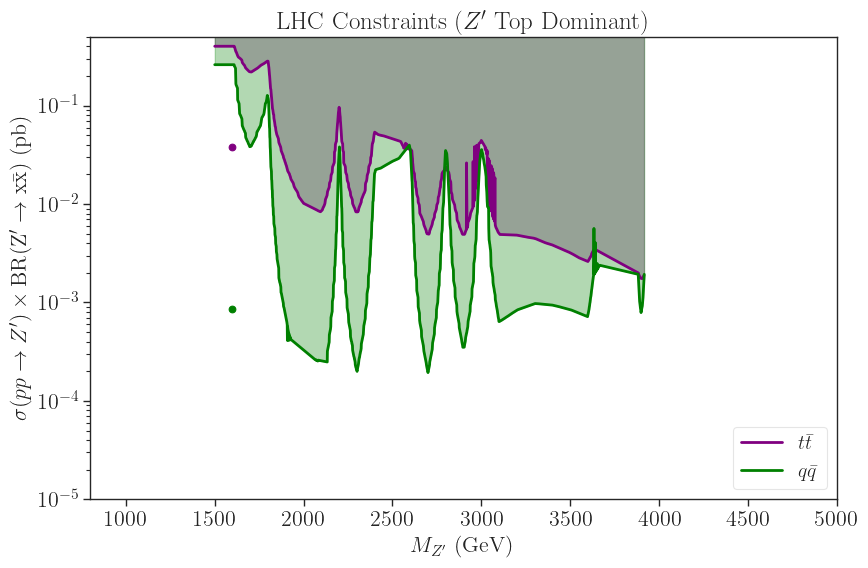

In [7]:
# 1. Load Data
df_qq = pd.read_csv('./Exclusion_Contours_topDom_qq.csv')
df_tt = pd.read_csv('./Exclusion_Contours_topDom_tt.csv')

r_target = 1.0 / 1.5
upper_limit = 0.5  

# ---------------------------------------------------------
# Create the Final Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(9, 6))

plot_simple_fill(df_tt, color='purple', label=r'$t\bar{t}$')
plot_simple_fill(df_qq, color='green', label=r'$q\bar{q}$')

# Formatting
plt.legend(loc='lower right', fontsize=14.5, framealpha=0.5)
plt.yscale('log')
plt.xlabel(r'$M_{Z^\prime}$ (GeV)', fontsize=16)
plt.ylabel(r'$\sigma(pp \to Z^\prime) \times \rm{BR}(Z^\prime \to x\bar{x})$ (pb)', fontsize=16)

plt.xlim(800, 5000)
plt.ylim(1e-5, upper_limit)
plt.scatter([1600],[0.037947/9.569138e-01 * 2.154309e-02], color = 'green', label = 'Current point')
plt.scatter([1600],[0.037947], color = 'purple', label = 'Current point')

plt.title(r'LHC Constraints ($Z^\prime$ Top Dominant)', fontsize=18)
plt.tight_layout()
plt.savefig('allExclusions_v2_Corrected.png', dpi=300)
plt.show()